In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import anacal
import numpy as np
import matplotlib.pylab as plt

import lsst.geom as geom
from numpy.lib import recfunctions as rfn
from astropy.visualization import simple_norm

from lsst.skymap.ringsSkyMap import (
    RingsSkyMap, RingsSkyMapConfig
)
from xlens.simulator.catalog import (
    CatalogTanCrossShearTask,
    CatalogTanCrossShearTaskConfig,
)
from xlens.simulator.sim import (
    MultibandSimConfig, MultibandSimTask
)

# Detection Task: Detect, shape measurement
from xlens.process_pipe.anacal_detect import (
    AnacalDetectPipeConfig, 
    AnacalDetectPipe,
)

# Skymap

In [77]:
dim = 4000
skymap_config = RingsSkyMapConfig()
skymap_config.patchInnerDimensions = [dim, dim]
skymap_config.tractOverlap = 0.0
skymap_config.patchBorder = 0
skymap_config.numRings = 7000
skymap_config.pixelScale = 0.2
skymap_config.projection = "TAN"
skymap = RingsSkyMap(config=skymap_config)

# Tangential/Cross Shear Task

In [78]:
cat_config = CatalogTanCrossShearTaskConfig()
cat_config.extend_ratio = 1.08
cat_config.kappa_value = 0.0
cat_config.test_value = 0.02
cat_config.layout = "grid"
cat_config.test_target = "gt"
cat_config.mode = 1
cattask = CatalogTanCrossShearTask(config=cat_config)
truth = cattask.run(
    tract_info=skymap[0],
    seed=0,
).truthCatalog

In [180]:
sim_config = MultibandSimConfig()
sim_config.survey_name = (
    "lsst" 
)
sim_config.force_isotropic = False
sim_config.draw_image_noise = False
simtask = MultibandSimTask(config=sim_config)

Text(0.5, 1.0, 'Exposure')

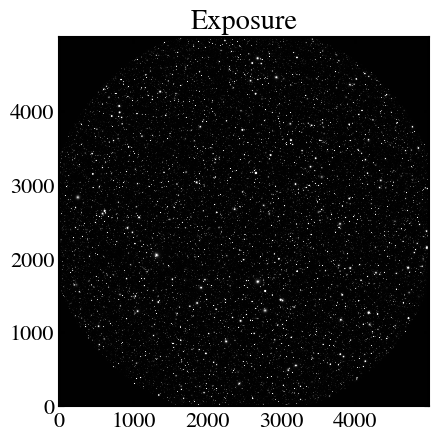

In [61]:
plt.imshow(
    gal_array,
    aspect="equal",
    cmap="Greys_r",
    origin="lower",
    interpolation="None",
    norm=simple_norm(gal_array, "asinh", asinh_a=0.2, min_cut=-0.1, max_cut=30),
)
plt.title("Exposure")

# Detect and Measure

In [181]:
# Detect and measure on the noiseless isotropic image
config_det_iso = AnacalDetectPipeConfig()
config_det_iso.anacal.force_size = False
config_det_iso.anacal.sigma_arcsec = 0.38
config_det_iso.anacal.num_epochs = 0
config_det_iso.anacal.do_noise_bias_correction = False  # noiseless
config_det_iso.anacal.validate_psf = False
config_det_iso.do_fpfs = True
config_det_iso.fpfs.sigma_shapelets1 = 0.38 * np.sqrt(2.0)
config_det_iso.fpfs.do_noise_bias_correction = False  # noiseless
config_det_iso.fpfs.return_only_linear_modes = False

tract_id = 0
patch_id = 0

det_task_iso = AnacalDetectPipe(config=config_det_iso)

In [182]:
n = 100
Rmax = np.sqrt((dim/2) **2 + (dim/2) ** 2)
nbins = 10
bins = np.logspace(1e-2, np.log10(Rmax), nbins + 1)

ets = np.zeros((n, nbins))
exs = np.zeros((n, nbins))
Rs = np.zeros((n, nbins))
wsels = np.zeros((n, nbins))

for i in range(n):
    print(i)
    truth = cattask.run(
        tract_info=skymap[0],
        seed=i,
    ).truthCatalog
    outcome = simtask.run(
        tract_info=skymap[0],
        patch_id=0,
        band="i",
        seed=i,
        truthCatalog=truth,
    )
    gal_array = np.asarray(
        outcome.simExposure.getMaskedImage().getImage().array,
        np.float64,
    )
    lsst_psf = outcome.simExposure.getPsf()
    psf_array = np.asarray(
        anacal.utils.resize_array(
            lsst_psf.computeImage(
                geom.Point2D(250, 250)
            ).getArray(), (64, 64)
        ),
        dtype=np.float64,
    )
    data_iso = det_task_iso.anacal.prepare_data(
        exposure=outcome.simExposure,
        seed=seed_iso,
        noise_corr=None,
        detection=None,
        band="i",
        skyMap=skymap,
        tract=tract_id,
        patch=patch_id,
    )
    catalog_iso = det_task_iso.run_measure(data_iso)
    wcs = outcome.simExposure.getWcs()
    xc, yc = (dim-1)/2, (dim-1)/2
    x, y = wcs.skyToPixelArray(catalog_iso["ra"], catalog_iso["dec"], degrees=True)
    source_phi = np.arctan2(
            y - (dim-1)/2,
            x - (dim-1)/2
        )
    rot = np.exp(-2j * source_phi)
    e1 = catalog_iso["wsel"] * catalog_iso["fpfs_e1"]
    de1 = catalog_iso["dwsel_dg1"] * catalog_iso["fpfs_e1"] + catalog_iso["wsel"] * catalog_iso["fpfs_de1_dg1"]

    e2 = catalog_iso["wsel"] * catalog_iso["fpfs_e2"]
    de2 = catalog_iso["dwsel_dg2"] * catalog_iso["fpfs_e2"] + catalog_iso["wsel"] * catalog_iso["fpfs_de2_dg2"]
    wsel = catalog_iso["wsel"]

    res = 0.5 * (de1 + de2)

    e_rot = -(e1 + 1j * e2) * rot
    et, ex = e_rot.real, e_rot.imag

    r = np.sqrt((x - xc) ** 2 + (y - yc) ** 2)
    bin_indices = np.digitize(r, bins)
    
    for b in range(1, nbins + 1):
        mask = (bin_indices == b)
        ets[i, b-1] = np.sum(et[mask])
        exs[i, b-1] = np.sum(ex[mask])
        Rs[i, b-1] = np.sum(res[mask])
        wsels[i, b-1] = np.sum(wsel[mask])
        

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


# Shear Recovery

In [183]:
# no binning
gt = np.mean(np.sum(ets, axis=1) / np.sum(Rs, axis=1))
gx = np.mean(np.sum(exs, axis=1) / np.sum(Rs, axis=1))
print(f"gt = {gt:.6f} (expected ~0.02)")
print(f"gx = {gx:.6f} (expected ~0)")


gt = 0.019923 (expected ~0.02)
gx = -0.000004 (expected ~0)


In [141]:
gt_b

array([       nan,        nan,        nan,        nan,        nan,
       0.01871638, 0.0185144 , 0.01999856, 0.0197512 , 0.02020543])

/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1215821497.py:4: RuntimeWarning: invalid value encountered in divide
  gt_b = np.mean(ets, axis=0) / np.mean(Rs, axis=0)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1215821497.py:5: RuntimeWarning: invalid value encountered in divide
  gt_be = np.std(ets, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1215821497.py:6: RuntimeWarning: invalid value encountered in divide
  gx_b = np.mean(exs, axis=0) / np.mean(Rs, axis=0)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1215821497.py:7: RuntimeWarning: invalid value encountered in divide
  gx_be = np.std(exs, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)


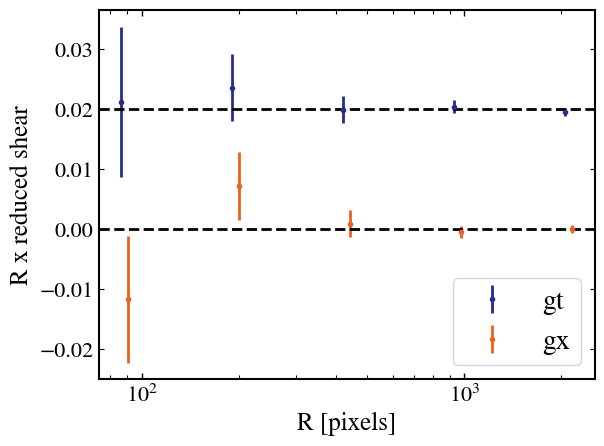

In [184]:
bin_centers = 0.5 * (bins[1:] + bins[:-1])
area = np.pi * (bins[1:]**2 - bins[:-1]**2)
input_gt = 0.02
gt_b = np.mean(ets, axis=0) / np.mean(Rs, axis=0)
gt_be = np.std(ets, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)
gx_b = np.mean(exs, axis=0) / np.mean(Rs, axis=0)
gx_be = np.std(exs, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)

plt.errorbar(bin_centers, gt_b, gt_be, fmt='.', label='gt')
plt.axhline(input_gt, c='k', ls='--')
plt.errorbar(bin_centers * 1.05, gx_b, gx_be, fmt='.', label='gx')
plt.axhline(0, c='k', ls='--')
plt.xlabel('R [pixels]')
plt.ylabel('R x reduced shear')
plt.legend()
plt.xscale('log')

In [ ]:
catalog_iso

/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/2252748388.py:5: RuntimeWarning: invalid value encountered in divide
  gt_b = np.mean(ets[:num], axis=0) / np.mean(Rs[:num], axis=0)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/2252748388.py:6: RuntimeWarning: invalid value encountered in divide
  gt_be = np.std(ets[:num], axis=0) / np.mean(Rs[:num], axis=0) / np.sqrt(n)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/2252748388.py:7: RuntimeWarning: invalid value encountered in divide
  gx_b = np.mean(exs[:num], axis=0) / np.mean(Rs[:num], axis=0)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/2252748388.py:8: RuntimeWarning: invalid value encountered in divide
  gx_be = np.std(exs[:num], axis=0) / np.mean(Rs[:num], axis=0) / np.sqrt(n)


chi2 consistency test gives 0.8118797221543235


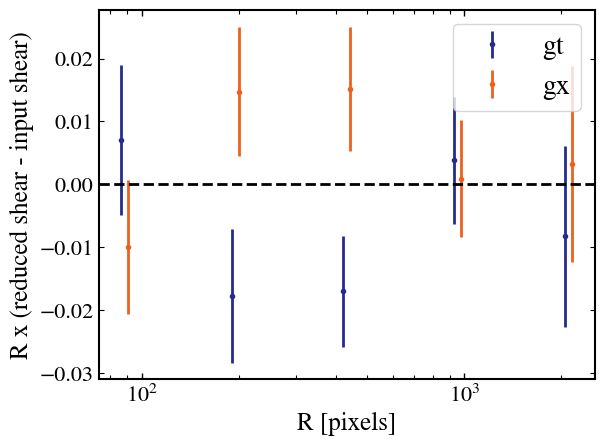

In [186]:
bin_centers = 0.5 * (bins[1:] + bins[:-1])
area = np.pi * (bins[1:]**2 - bins[:-1]**2)
input_gt = 0.02
num = 50
gt_b = np.mean(ets[:num], axis=0) / np.mean(Rs[:num], axis=0)
gt_be = np.std(ets[:num], axis=0) / np.mean(Rs[:num], axis=0) / np.sqrt(n)
gx_b = np.mean(exs[:num], axis=0) / np.mean(Rs[:num], axis=0)
gx_be = np.std(exs[:num], axis=0) / np.mean(Rs[:num], axis=0) / np.sqrt(n)

plt.errorbar(bin_centers, (gt_b - input_gt) * bin_centers / 100, gt_be * bin_centers / 100, fmt='.', label='gt')
plt.errorbar(bin_centers * 1.05, gx_b * bin_centers / 100, gx_be * bin_centers / 100, fmt='.', label='gx')
plt.axhline(0, c='k', ls='--')
plt.xlabel('R [pixels]')
plt.ylabel('R x (reduced shear - input shear)')
plt.legend()
plt.xscale('log')


mask = np.isfinite(gt_be)
chi2_t = np.sum(((gt_b[mask] - input_gt)**2) / (gt_be[mask]**2))
dof_t = len(gt_b) - 1  # 1 parameter (constant model)

chi2_t_red = chi2_t / dof_t
print("chi2 consistency test gives", chi2_t / dof_t)

In [168]:
import fitsio
test = fitsio.read('/Users/andypark/Desktop/shear/catsim-v4/OneDegSq.fits')

In [172]:
catalog = fitsio.read('/Users/andypark/Desktop/shear/catsim-v4/OneDegSq.fits')
density = len(catalog) / 60 / 60

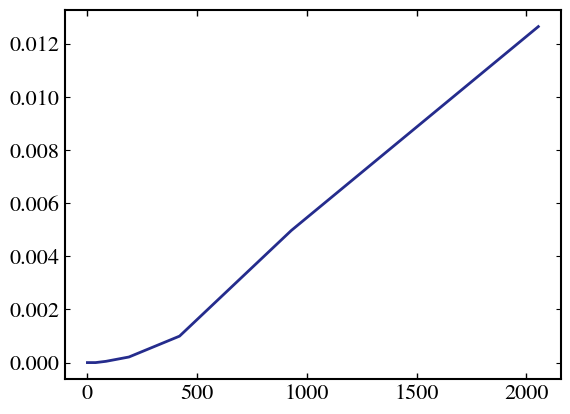

In [176]:
plt.plot(bin_centers, np.average(wsels, axis=0) * (0.2 / 60) ** 2)

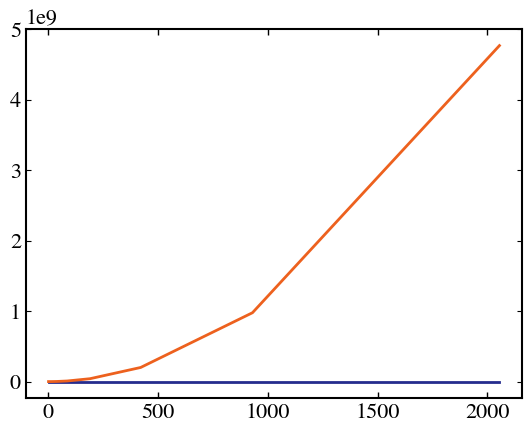

In [174]:
plt.plot(bin_centers, np.average(wsels, axis=0))
plt.plot(bin_centers, density * area)

In [161]:

mask = np.isfinite(gt_be)
chi2_t = np.sum(((gt_b[mask] - input_gt)**2) / (gt_be[mask]**2))
dof_t = len(gt_b) - 1  # 1 parameter (constant model)

chi2_t_red = chi2_t / dof_t

In [134]:
chi2_t, chi2_t_red

(np.float64(0.62990948537274), np.float64(0.10498491422879001))

/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1297798121.py:4: RuntimeWarning: invalid value encountered in divide
  gt_b = np.mean(ets, axis=0) / np.mean(Rs, axis=0)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1297798121.py:5: RuntimeWarning: invalid value encountered in divide
  gt_be = np.std(ets, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1297798121.py:6: RuntimeWarning: invalid value encountered in divide
  gx_b = np.mean(exs, axis=0) / np.mean(Rs, axis=0)
/var/folders/5l/rq5vkq992vj1d3m9hkc2ddpm0000gn/T/ipykernel_4858/1297798121.py:7: RuntimeWarning: invalid value encountered in divide
  gx_be = np.std(exs, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)


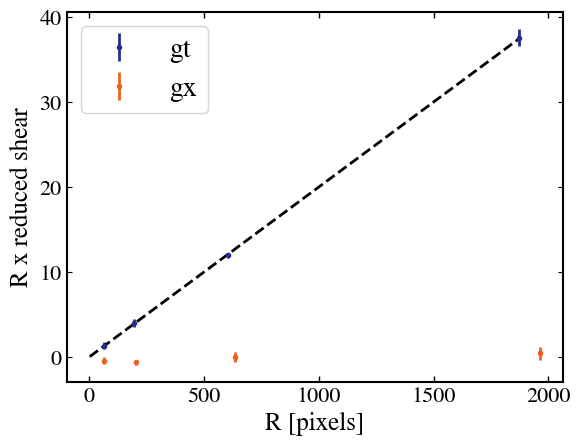

In [120]:
bin_centers = 0.5 * (bins[1:] + bins[:-1])
area = np.pi * (bins[1:]**2 - bins[:-1]**2)
input_gt = 0.02
gt_b = np.mean(ets, axis=0) / np.mean(Rs, axis=0)
gt_be = np.std(ets, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)
gx_b = np.mean(exs, axis=0) / np.mean(Rs, axis=0)
gx_be = np.std(exs, axis=0) / np.mean(Rs, axis=0) / np.sqrt(n)

plt.errorbar(bin_centers, gt_b * bin_centers, gt_be * bin_centers, fmt='.', label='gt')
plt.plot(bin_centers, input_gt * bin_centers, c='k', ls='--')
plt.errorbar(bin_centers * 1.05, gx_b * bin_centers, gx_be * bin_centers, fmt='.', label='gx')
plt.plot(0, c='k', ls='--')
plt.xlabel('R [pixels]')
plt.ylabel('R x reduced shear')
plt.legend()

In [ ]:




rot = np.exp(-2j * source_phi)

e_rot = -(e1 + 1j * e2) * rot
R_rot = (de1 + 1j * de2) * rot

et, ex = e_rot.real, e_rot.imag
Rt, Rx = R_rot.real, R_rot.imag

In [63]:
np.sum(et) / np.sum(res)

np.float64(0.021026472298320328)

In [58]:
res = 0.5 * (de1 + de2)
gt = np.mean(et) / np.mean(res)
gx = np.mean(ex) / np.mean(res)

In [59]:
gt, gx

(np.float64(0.021026472298320328), np.float64(-0.0008556290220681458))